## EXPLORATORY DATA ANALYSIS

In [3]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_colwidth', None)

In [5]:
df = pd.read_csv(r"C:\Users\acer\OneDrive\Desktop\College Work\SEM 6\FINAL PROJECT\data\yelp_reviews.csv")
df.head()

,business_id,review_text,rating
0,fqyJZMsKG-oWSGdZIftQgQ,"I absolutely loved coming here until today. I even received excellent customer service today! Although, when I saw the steak to my steak and egg bagel being finished on the grill, the guy that was cooking it ate a piece of steak with his fingers right off of the bagel. I just imagined how many other bagels he prepared with the same gloves on. Ruined my appetite - please make sure the kitchen staff are not eating! Especially eating from the food that is being served... there's windows!",2
1,ozOneB4jXOD6hv5WBGj4KQ,Exceeded our expectations in every way. Go early and parking is easy.,5
2,BWkiW0r0h7ytdbWMhay7wA,I came here recently after a big group event. We had told him before that we were coming and were told that we would be getting a group discount of a dollar off each beer for the first beer. We got here and no one seems to know about the arrangement. I don't know if it was management the bartender or our party planner in the group that dropped the ball. When we got there the bartender wasn't particularly rude but they weren't particularly nice. They seemed kind of annoyed at the fact that we were going to have such a big group. Maybe they were understaffed. I can honestly say they seem to know their beer and did a proper pour. The flights are very reasonably priced. So was the Grawler.there is plenty of parking. They were supposed to have a food truck that day but it was so crowded and the food truck I took forever. My group actually ordered out takeout and ate it in the facility. There's plenty of space so you're not on top of each other. I like that they don't have TVs. You actually have to talk to each other. I like that their puppy friendly. I got a growler of the chocolate peanut butter stout to go. It's amazing. I will definitely be back here becauseThe quality of beer is really nice. This is a real gem for Tampa Bay.,4
3,Og4z8nB4ZMZs3oHkVhB_pA,I went to get my hair cut and colored at Bobby Mack last night and it was more than wonderful. Andy is definitely a pro and has a creative mind. He walked me through my indecisiveness and my hair came out amazing!! I have been living in Philly for 8 years and I finally found my hair salon!!!! Woo,5
4,I1H5s9cVCGh1nH-4bhsSDA,"My review shall be fair and balanced. Not in a Fox News kind of way, but really, truly so.\n\nI have eaten at Santucci's twice, gotten take out once, and had delivery once. I have tried many things both on and off the menu, and I must say, I love this place. It's one of my new favorites in Philly, regardless of price.\n\nI don't generally like thicker crust pizzas. For the most part, my favorite Philly pizza spots sell extremely thin crust pies. Barbuzzo, Osteria, Zavino, and Slice are on the thin end of the pizza spectrum. i tend to stay on that end. Thick crusts remind me of my ""ignorance is bliss"" youth of eating greasy Pizza Hut. I was a chubby child.\n\nWhen I first saw a Santucci's square pizza, I wasn't really impressed. It looked like a tomato pie, as the cheese is placed between the crust and sauce. meh. But after my first bite, I was both impressed by the quality and flavor of the crust, and by the how well the toppings and ratio of the toppings to crust worked. It's just damn good pizza. However, there's so much more to Santucci's. I could go there every day, not get pizza, and be totally happy. \n\nIf you look on the wall of the restaurant, there's a blackboard with the day's specials. If I recall correctly, their current theme is ""fall harvest."" On two occasions, I had the pasta special- trofie with mushrooms, butternut squash, walnuts, and a couple of cheeses. Trofie's a toothsome hand made gnocchi type thing, but pretty thin. It's got some definite texture to it, which caught me off guard. I wondered whether it was under cooked, but after a few more bites, it made sense. The texture of the trofie, the earthiness of the mushrooms, the crunch of the occasional walnut, accompanied by t

In [6]:
df.shape
df.columns

Index(['business_id', 'review_text', 'rating'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  20000 non-null  object
 1   review_text  20000 non-null  object
 2   rating       20000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 468.9+ KB


In [8]:
#Since there are no missing values, no need to remove any rows
df.isnull().sum()

business_id    0
review_text    0
rating         0
dtype: int64

In [9]:
# Confirming that there are multiple reviews per Business
df['business_id'].nunique()
df['business_id'].value_counts().head()

business_id
#NAME?                    266
_ab50qdWOk0DdB6XOrBitw     23
oBNrLz4EDhiscSlbOl8uAw     20
ytynqOUb3hjKeJfRj5Tshw     20
GBTPC53ZrG1ZBY3DT8Mbcw     18
Name: count, dtype: int64

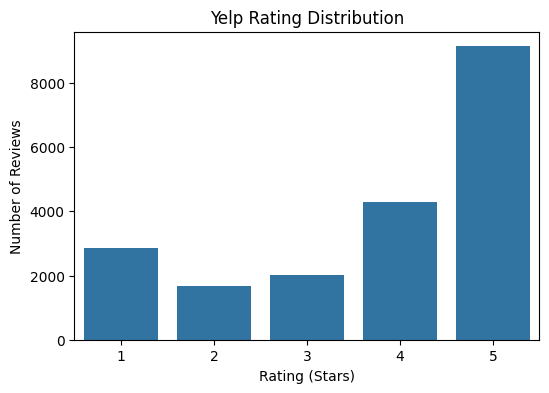

In [10]:
#Checking Rating Distributions
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title("Yelp Rating Distribution")
plt.xlabel("Rating (Stars)")
plt.ylabel("Number of Reviews")
plt.show()

Observation: From the rating distribution plot, we can see that yelp reviews are very biased towards higher stars (4Star and 5Star reviews), but it is still not as biased as amazon reviews, where an overwhelming majority of reviews are 5 star or 4 star

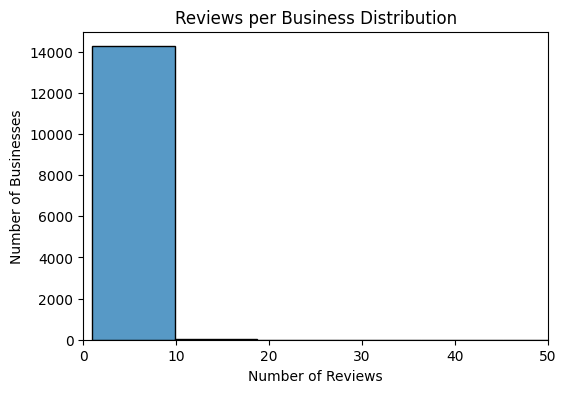

In [11]:
# Number of reviews per business distribution
reviews_per_business = df['business_id'].value_counts()

plt.figure(figsize=(6,4))
sns.histplot(reviews_per_business, bins=30)
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Businesses")
plt.title("Reviews per Business Distribution")
plt.xlim(0,50)
plt.show()

Observation: A lot of businesses have multiple reviews, but most are capped to under 10 reviews max

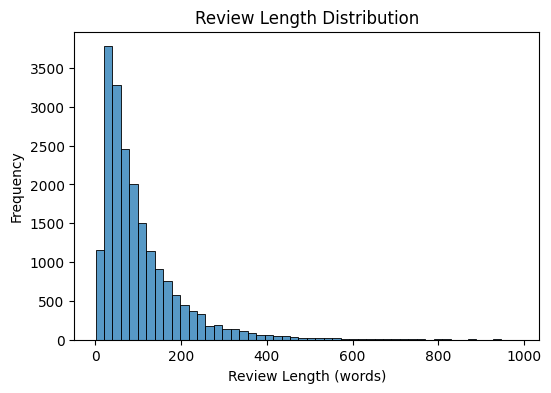

In [12]:
# Length of reviews distribution
df['review_length'] = df['review_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(6,4))
sns.histplot(df['review_length'], bins=50)
plt.xlabel("Review Length (words)")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")
plt.show()

In [13]:
# Manual review inspection
for review in df['review_text'].sample(3):
    print("REVIEW:")
    print(review)
    print("-" * 80)

REVIEW:
Had the Turkey Ribs and Potato Salad.
Excellent prices and the turkey ribs were spectacular.
--------------------------------------------------------------------------------
REVIEW:
My partner and I had booked a dinner reservation at Aura before a big event the night after Valentine's day. We arrived promptly at the time of our reservation and was sat by the hostess. The menus were cheap and covered in food particles from previous patrons and the restaurant was nearly empty. I was dressed in a gown and my partner in a feminine suit. We waited so long for service that we already had all of our drinks, apps and entrees picked out before we even received a table greet. After over 15 minutes of waiting the hostess sat a couple at the table right next to us and they were served immediately. We were never served. We got up from our tables and left to spend our money elsewhere. My partner and I are both managers in Hospitality and  know this was inexcusable. I am not 100% sure they in

Final obervations post eda

-> Yelp reviews show a moderate bias towards higher star ratings

-> Businesses have varying numbers of reviews, enabling aggregation

-> Review lengths vary significantly, indicating potential abnormal patterns

-> Manual inspection reveals promotional and exaggerated language in some reviews

## TEXT PRE-PROCESSING

In [16]:
# Import Libraries
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [15]:
# Intialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
# Define a single function to preprocess the text
def preprocess_text(text):
    # Lowercasing
    text = text.lower()
    
    # Removing URLs using regex
    text = re.sub(r'http\S+', '', text)
    
    # Removing special characters and numbers using regex
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenization
    tokens = nltk.word_tokenize(text)
    
    # Stopword removal + lemmatization
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    
    return " ".join(cleaned_tokens)

In [ ]:
# Apply the preprocessing function ot the dataframe and put the preprocessed text into a new column called 'clean_review'
df['clean_review'] = df['review_text'].apply(preprocess_text)

In [20]:
df[['review_text', 'clean_review']].head()

,review_text,clean_review
0,"I absolutely loved coming here until today. I even received excellent customer service today! Although, when I saw the steak to my steak and egg bagel being finished on the grill, the guy that was cooking it ate a piece of steak with his fingers right off of the bagel. I just imagined how many other bagels he prepared with the same gloves on. Ruined my appetite - please make sure the kitchen staff are not eating! Especially eating from the food that is being served... there's windows!",absolutely loved coming today even received excellent customer service today although saw steak steak egg bagel finished grill guy cooking ate piece steak finger right bagel imagined many bagel prepared glove ruined appetite please make sure kitchen staff eating especially eating food served there window
1,Exceeded our expectations in every way. Go early and parking is easy.,exceeded expectation every way go early parking easy
2,I came here recently after a big group event. We had told him before that we were coming and were told that we would be getting a group discount of a dollar off each beer for the first beer. We got here and no one seems to know about the arrangement. I don't know if it was management the bartender or our party planner in the group that dropped the ball. When we got there the bartender wasn't particularly rude but they weren't particularly nice. They seemed kind of annoyed at the fact that we were going to have such a big group. Maybe they were understaffed. I can honestly say they seem to know their beer and did a proper pour. The flights are very reasonably priced. So was the Grawler.there is plenty of parking. They were supposed to have a food truck that day but it was so crowded and the food truck I took forever. My group actually ordered out takeout and ate it in the facility. There's plenty of space so you're not on top of each other. I like that they don't have TVs. You actually have to talk to each other. I like that their puppy friendly. I got a growler of the chocolate peanut butter stout to go. It's amazing. I will definitely be back here becauseThe quality of beer is really nice. This is a real gem for Tampa Bay.,came recently big group event told coming told would getting group discount dollar beer first beer got one seems know arrangement dont know management bartender party planner group dropped ball got bartender wasnt particularly rude werent particularly nice seemed kind annoyed fact going big group maybe understaffed honestly say seem know beer proper pour flight reasonably priced grawlerthere plenty parking supposed food truck day crowded food truck took forever group actually ordered takeout ate facility there plenty space youre top like dont tv actually talk like puppy friendly got growler chocolate peanut butter stout go amazing definitely back becausethe quality beer really nice real gem tampa bay
3,I went to get my hair cut and colored at Bobby Mack last night and it was more than wonderful. Andy is definitely a pro and has a creative mind. He walked me through my indecisiveness and my hair came out amazing!! I have been living in Philly for 8 years and I finally found my hair salon!!!! Woo,went get hair cut colored bobby mack last night wonderful andy definitely pro creative mind walked indecisiveness hair came amazing living philly year finally found hair salon woo
4,"My review shall be fair and balanced. Not in a Fox News kind of way, but really, truly so.\n\nI have eaten at Santucci's twice, gotten take out once, and had delivery once. I have tried many things both on and off the menu, and I must say, I love this place. It's one of my new favorites in Philly, regardless of price.\n\nI don't generally like thicker crust pizzas. For the most part, my favorite Philly pizza spots sell extremely thin crust pies. Barbuzzo, Osteria, Zavino, and Slice are on the thin end of the pizza spectrum. i tend to stay on that end. Thick crusts remind me of my ""ignorance is bliss"" 

In [ ]:
# save the dataset with clean reviews to csv format for further use
df.to_csv("yelp_reviews_clean.csv", index=False)

## EDA AND PREPROCESSING COMPLETED